In [1]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np
import sys
import pickle
import json

sys.path.insert(0, "../../../utils")

from modules import *

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, log_loss, mean_absolute_error, mean_squared_error
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer
from Model_Validation_Module import *

enc = 'utf-8'

REGION = 'Nord'

TARGET = ''

In [2]:
dataframe = pd.read_csv(f'../../../data/{REGION}/CM_{REGION}_Dataset_2015-2024.csv', encoding=enc)

In [3]:
dataframe.sort_values(["dt_prediction", "GID0", "GID1", "GID2", "GID3"], inplace=True)

dataframe['location'] = list(zip(dataframe['GID0'], dataframe['GID1'], dataframe['GID2'], dataframe['GID3']))
dataframe.drop(columns=['GID0', 'GID1', 'GID2', 'GID3', 'year', 'month', 'dt_recorded_cases', 'dt_weather_acc', 'year_biovars', 'year_lc'], inplace=True)
dataframe['dt_prediction'] = pd.to_datetime(dataframe['dt_prediction']).dt.to_period('M')

dataframe = dataframe[['location'] + dataframe.columns.to_list()[:-1]]

In [4]:
dataframe.drop(columns=['Case_UND5', 'Case_OVR5', 'Case_PRGN', 
                      'Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN', 'Sevr_TOTAL',
                      'Hosp_UND5', 'Hosp_OVR5', 'Hosp_PRGN', 'Hosp_TOTAL',
                      'Death_UND5', 'Death_OVR5', 'Death_PRGN', 'Death_TOTAL'], inplace=True)

dataframe.rename(columns={'Case_TOTAL': 'cases'}, inplace=True)

In [5]:
rainfall_cols = [col for col in dataframe.columns if 'rainfall' in col]
lst_cols = [col for col in dataframe.columns if 'lst' in col]
bio_cols = [col for col in dataframe.columns if 'bio' in col]
geo_cols = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m']
geo_cols += [f"{col}_std" for col in geo_cols]

round_cols = [rainfall_cols, lst_cols, bio_cols, geo_cols]
round_factor = [4,2,2,2]

In [ ]:
with open(f'saved/CM_{REGION}_bin_ranges{TARGET}.pkl', 'rb') as f:
    bin_ranges = pickle.load(f)

In [7]:
num_of_classes = len(bin_ranges) - 1
print(f'Number of classes: {num_of_classes}')

Number of classes: 8


In [8]:
risk_classes = list(range(0,num_of_classes))
risk_classes

[0, 1, 2, 3, 4, 5, 6, 7]

In [9]:
bins, bounds = pd.cut(x = dataframe.loc[:, 'cases'], bins=bin_ranges, right=False, include_lowest=True, labels=risk_classes, retbins=True, precision=0)

In [10]:
dataframe['case_bin'] = bins

In [11]:
dataset = dataframe.copy()

In [12]:
dataset['case_bin'] = pd.Categorical(dataset['case_bin'])

In [13]:
# bounds = np.concatenate(([0], bounds))
bounds = np.array(bounds, dtype=int)
print(f'Bounds: {bounds}')

Bounds: [   0    1   16   32   64  128  256  512 3666]


In [14]:
dataset.sort_values(["dt_prediction", "location"], inplace=True)
dataset.reset_index(drop=True, inplace=True)

In [15]:
dataset

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases,case_bin
0,"(nord, benoue, bibemi, adoumri)",13.770202,9.240232,2014-10,-0.866,0.5,0.542311,0.148177,-0.365296,-0.148177,...,1888.0,489.0,2.0,108.60,1224.0,24.0,243.0,1224.0,106,4
1,"(nord, benoue, bibemi, bibemi)",13.949181,9.263633,2014-10,-0.866,0.5,0.499024,0.112709,-0.351063,-0.112709,...,1905.0,544.0,1.0,113.49,1283.0,20.0,247.0,1283.0,85,4
2,"(nord, benoue, bibemi, bide)",13.972945,9.422292,2014-10,-0.866,0.5,0.491692,0.119406,-0.338767,-0.119406,...,1732.0,513.0,0.0,119.68,1209.0,4.0,46.0,1209.0,30,2
3,"(nord, benoue, bibemi, dengui)",13.642496,9.235656,2014-10,-0.866,0.5,0.511243,0.171523,-0.300408,-0.171523,...,1922.0,503.0,3.0,105.80,1210.0,24.0,271.0,1210.0,43,3
4,"(nord, benoue, bibemi, djaloumi)",13.994667,9.585190,2014-10,-0.866,0.5,0.505574,0.198941,-0.280563,-0.198941,...,1725.0,471.0,0.0,117.97,1200.0,5.0,194.0,1200.0,29,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16948,"(nord, mayo-rey, touboro, mbeing)",15.001895,7.650008,2024-09,-1.000,0.0,0.444202,0.246985,-0.353127,-0.246985,...,2746.0,582.0,0.0,91.49,1488.0,0.0,205.0,1488.0,59,3
16949,"(nord, mayo-rey, touboro, ngai-lara)",15.110765,7.963850,2024-09,-1.000,0.0,0.594980,0.262238,-0.460305,-0.262238,...,2791.0,626.0,0.0,97.38,1598.0,0.0,175.0,1598.0,126,4
16950,"(nord, mayo-rey, touboro, touboro)",15.293957,7.759324,2024-09,-1.000,0.0,0.592537,0.214245,-0.454020,-0.214245,...,2842.0,589.0,0.0,94.80,1630.0,2.0,462.0,1630.0,656,7
16951,"(nord, mayo-rey, touboro, vogzom)",14.714359,7.747549,2024-09,-1.000,0.0,0.599925,0.240514,-0.463363,-0.240514,...,2527.0,490.0,0.0,93.43,1316.0,0.0,163.0,1316.0,403,6


In [16]:
X = dataset.select_dtypes(exclude=['object', 'period[M]']).drop(columns=['cases', 'case_bin'])
y = dataset['case_bin']

n_folds = 10
k_fold = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = 0)

In [17]:
features_to_remove = []

feature_names = X.drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['x', 'y', 'month_sin', 'month_cos', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_min_prev_month', 'lst_max_prev_month', 'rainfall', 'rainfall_acc_prev_month', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'distance_to_coast_std', 'distance_to_river_std', 'slope_mean_1km_std', 'aspect_mean_200m_std', 'elevation_mean_1km_std', 'hillshade_mean_1km_std', 'fs_area_1km_std', 'flow_accu_200m_std', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19']
Total Features Used: 66


In [ ]:
with open(f'saved/CM_{REGION}_rfecv_model{TARGET}.pkl', "rb") as f:
    fitted_rfe = pickle.load(f)

In [ ]:
with open(f'saved/CM_{REGION}_gridcv_best_params{TARGET}.json', "r") as f:
    model_params = json.load(f)

In [20]:
fold_counter = 0
n_models = 10 

y_true_list = []
y_pred_list = []
y_index_list = []

for train_idx, test_idx in k_fold.split(X, y):
    print(f'Fold: {fold_counter+1}/{n_folds}')

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    imputer = KNNImputer(n_neighbors=3)
    imputer.fit(X_train_scaled)
    X_train_imputed = pd.DataFrame(imputer.transform(X_train_scaled), columns=X_train.columns, index=X_train.index)
    X_test_imputed = pd.DataFrame(imputer.transform(X_test_scaled), columns=X_test.columns, index=X_test.index)

    X_train_imputed = pd.DataFrame(scaler.inverse_transform(X_train_imputed), columns=X_train.columns, index=X_train.index)
    X_test_imputed = pd.DataFrame(scaler.inverse_transform(X_test_imputed), columns=X_test.columns, index=X_test.index)

    X_train_imputed = round_columns(X_train_imputed, round_cols, round_factor)
    X_test_imputed = round_columns(X_test_imputed, round_cols, round_factor)

    X_train_rfe = pd.DataFrame(fitted_rfe.transform(X_train_imputed), columns = X.columns[fitted_rfe.support_], index=X_train.index)
    X_test_rfe = pd.DataFrame(fitted_rfe.transform(X_test_imputed), columns = X.columns[fitted_rfe.support_], index=X_test.index)

    ## --- Ensemble Model Training ---
    y_pred_ensemble_list = []

    for model in range(n_models):
        print(f"\tEnsemble Model {model+1}/{n_models}", end='\r')
        ensemble_params = model_params.copy()
        ensemble_params['subsample'] = 0.8
        ensemble_params['colsample_bytree'] = 0.8
        ensemble_params['seed'] = model * 100 + fold_counter

        model = xgb.XGBRegressor(**ensemble_params)   
        fitted_model = model.fit(X_train_rfe, y_train, verbose=False)

        y_pred = fitted_model.predict(X_test_rfe)

        y_pred_ensemble_list.append(y_pred)

    y_true_list.append(y_test)
    y_pred_list.append(y_pred_ensemble_list)
    y_index_list.append(test_idx)

    fold_counter += 1
    print('\n', end='\r')

Fold: 1/10
	Ensemble Model 10/10
Fold: 2/10
	Ensemble Model 10/10
Fold: 3/10
	Ensemble Model 10/10
Fold: 4/10
	Ensemble Model 10/10
Fold: 5/10
	Ensemble Model 10/10
Fold: 6/10
	Ensemble Model 10/10
Fold: 7/10
	Ensemble Model 10/10
Fold: 8/10
	Ensemble Model 10/10
Fold: 9/10
	Ensemble Model 10/10
Fold: 10/10
	Ensemble Model 10/10


In [21]:
y_true = np.concatenate(y_true_list, axis=0)
y_preds = [np.column_stack(pred) for pred in y_pred_list]
y_pred = np.vstack(y_preds)
# y_pred = np.clip(np.round(y_pred), 0, 9).astype(int)
y_pred = np.clip(y_pred, 0, num_of_classes-1)
y_index = np.concatenate(y_index_list, axis=0)

In [22]:
ens_columns = [f"ens_{i+1}" for i in range(y_pred.shape[1])]

df_ensembles = pd.DataFrame(
    data=y_pred,
    index=y_index,
    columns=ens_columns
)

df_ensembles['y_true'] = y_true
df_ensembles.sort_index(inplace=True)

In [23]:
# Mean prediction (ensemble average)
df_ensembles['y_pred_mean'] = df_ensembles[ens_columns].mean(axis=1)

# Uncertainty (std dev of ensemble predictions)
df_ensembles['y_uncertainty'] = df_ensembles[ens_columns].std(axis=1)

In [24]:
from scipy.stats import norm

z = norm.ppf(0.975)  # ~1.96

df_ensembles['pred_lower'] = df_ensembles['y_pred_mean'] - z * df_ensembles['y_uncertainty']
df_ensembles['pred_upper'] = df_ensembles['y_pred_mean'] + z * df_ensembles['y_uncertainty']

In [25]:
df_ensembles

,ens_1,ens_2,ens_3,ens_4,ens_5,ens_6,ens_7,ens_8,ens_9,ens_10,y_true,y_pred_mean,y_uncertainty,pred_lower,pred_upper
0,3.595583,3.638671,3.799167,3.469685,3.741882,3.430975,3.555547,3.788815,2.952166,3.592707,4,3.556520,0.246155,3.074065,4.038974
1,4.051324,4.361491,4.215446,4.492504,4.460812,3.896616,4.231451,3.827649,4.063069,4.181185,4,4.178155,0.223112,3.740863,4.615447
2,2.358346,2.668620,2.957076,2.462996,2.458651,2.310277,2.437520,2.281853,2.461506,2.284510,2,2.468135,0.207028,2.062367,2.873904
3,2.187194,1.771838,2.092043,1.662548,2.046978,2.230240,1.937534,1.692491,1.683419,1.794662,3,1.909895,0.217134,1.484320,2.335469
4,2.446262,2.226604,2.407725,2.611305,2.254419,2.262765,2.299349,2.445909,2.134810,2.580145,2,2.366930,0.156710,2.059783,2.674076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16948,3.503650,3.928766,3.806340,3.516357,3.610517,3.808052,3.735833,4.071342,3.776769,3.879017,3,3.763664,0.180182,3.410514,4.116815
16949,5.028908,4.941948,5.222823,5.015396,4.964949,5.145350,4.816206,5.267700,5.084404,5.349387,4,5.083707,0.163645,4.762968,5.404446
16950,6.244174,6.498934,6.388814,6.299743,6.225589,6.181881,6.168088,6.152174,6.370364,6.150442,7,6.268021,0.118516,6.035734,6.500307
16951,5.473719,5.824955,5.740013,5.629552,5.693728,5.769247,5.875223,5.999217,5.857750,5.951924,6,5.781533,0.156462,5.474873,6.088193


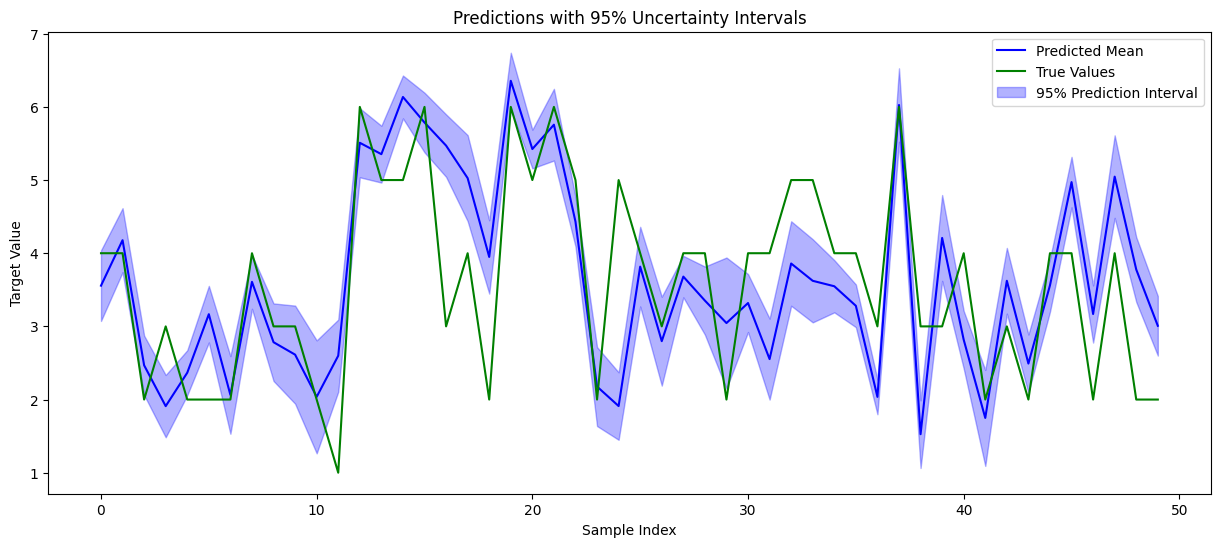

In [26]:
import matplotlib.pyplot as plt

# Select a subset (e.g., first 100 samples) to keep plot clear
subset = df_ensembles.iloc[:50]

plt.figure(figsize=(15,6))

# Plot mean prediction
plt.plot(subset.index, subset["y_pred_mean"], label="Predicted Mean", color="blue")

# Plot ground truth
plt.plot(subset.index, subset["y_true"], label="True Values", color="green")

# Fill between prediction intervals
plt.fill_between(
    subset.index,
    subset["pred_lower"],
    subset["pred_upper"],
    color="blue",
    alpha=0.3,
    label="95% Prediction Interval"
)

plt.xlabel("Sample Index")
plt.ylabel("Target Value")
plt.title("Predictions with 95% Uncertainty Intervals")
plt.legend()
plt.show()

In [27]:
df_ensembles_sorted = df_ensembles.sort_values(by='y_pred_mean').reset_index(drop=True)

In [28]:
df_ensembles_sorted.head()

,ens_1,ens_2,ens_3,ens_4,ens_5,ens_6,ens_7,ens_8,ens_9,ens_10,y_true,y_pred_mean,y_uncertainty,pred_lower,pred_upper
0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0,0.000000,0.000000,0.000000,0.000000
2,0.056212,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.025396,0.0,0,0.008161,0.018675,-0.028441,0.044762
3,0.000000,0.0,0.006924,0.0,0.0,0.000000,0.0,0.081418,0.000000,0.0,0,0.008834,0.025596,-0.041333,0.059002
4,0.000000,0.0,0.000000,0.0,0.0,0.121532,0.0,0.000000,0.000000,0.0,2,0.012153,0.038432,-0.063172,0.087478


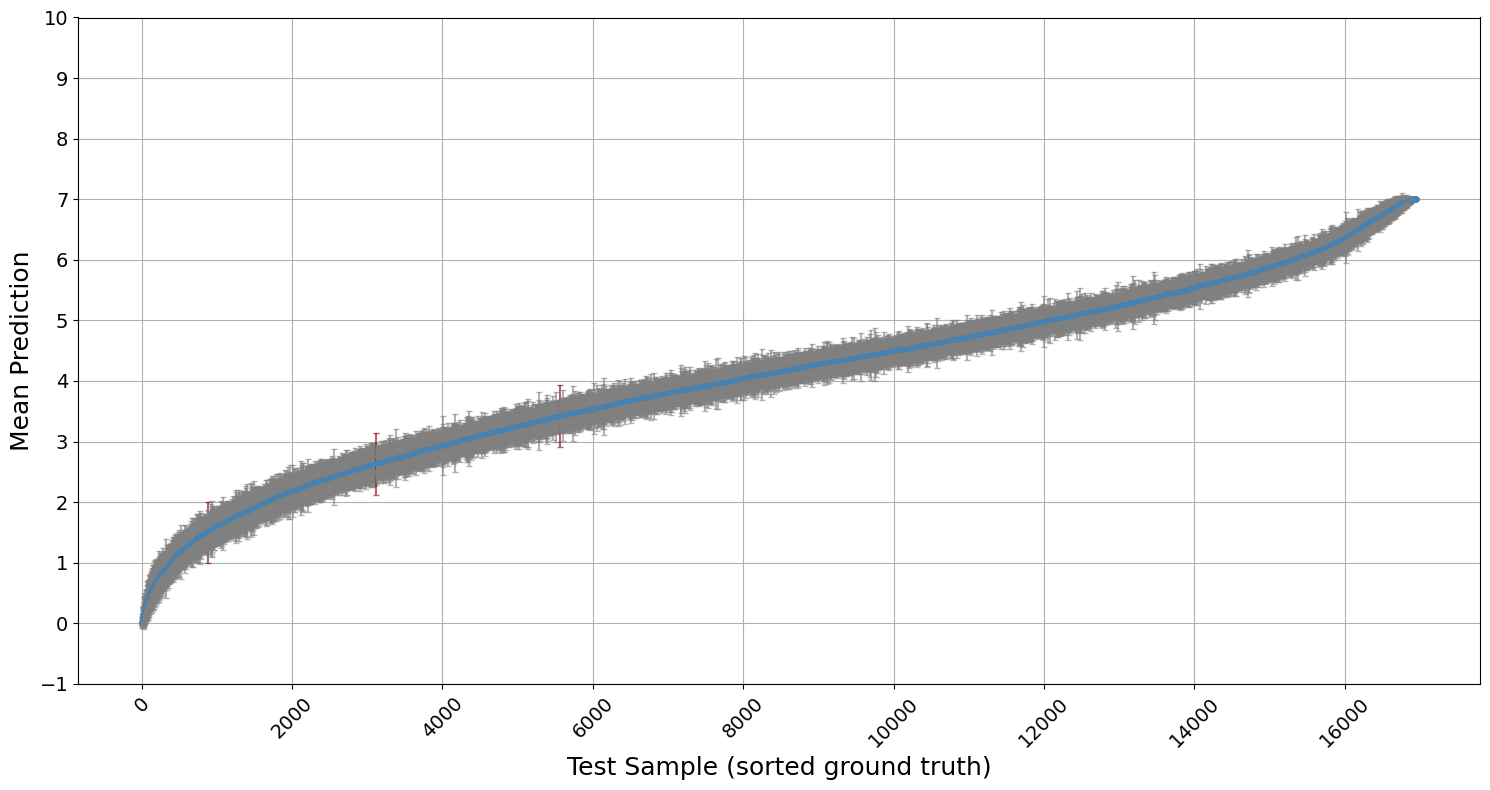

In [29]:
label_size = 18 
tick_size = 14
x_ticks_max = df_ensembles_sorted.shape[0]

plt.figure(figsize=(15, 8))

# Loop through each sample
for i in range(len(df_ensembles_sorted)):
    mean = df_ensembles_sorted['y_pred_mean'].iloc[i]
    std = df_ensembles_sorted['y_uncertainty'].iloc[i]
    
    err_color = '#7f0007' if std > 0.5 else 'gray'

    # Plot error bar only (no marker)
    plt.errorbar(
        x=i,
        y=mean,
        yerr=std,
        fmt='none',          # No marker
        ecolor=err_color,
        alpha=0.4 if err_color == 'grey' else 0.6,           # Alpha for error bars
        capsize=2
    )

    # Plot marker separately
    plt.plot(
        i,
        mean,
        'o',
        markersize=3,
        color='steelblue',       # Marker color
        alpha=1           # Alpha for marker
    )

plt.xlabel("Test Sample (sorted ground truth)", size=label_size)
plt.ylabel("Mean Prediction", size=label_size)
plt.yticks(np.arange(-1, 11, step=1), size=tick_size)
plt.xticks(np.arange(0, round(x_ticks_max * 1.05, -2), step=2000), size=tick_size)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [30]:
num_high_uncertainty = df_ensembles[df_ensembles['y_uncertainty'] >= 0.5].shape[0]
total_samples = df_ensembles.shape[0]
percentage_high_uncertainty = (num_high_uncertainty / total_samples) * 100
percentage_high_uncertainty

0.01769598301185631

In [31]:
print(f"Average Uncertainty of Predictions: {df_ensembles['y_uncertainty'].mean():.4f}")
print(f"High-risk Uncertainty of Predictions: {df_ensembles[df_ensembles['y_pred_mean'] >= 5]['y_uncertainty'].mean():.4f}")
print(f"Low-risk Uncertainty of Predictions: {df_ensembles[df_ensembles['y_pred_mean'] < 5]['y_uncertainty'].mean():.4f}")

Average Uncertainty of Predictions: 0.1714
High-risk Uncertainty of Predictions: 0.1437
Low-risk Uncertainty of Predictions: 0.1826


In [32]:
print(f"Average Std Dev of Predictions: {df_ensembles['y_uncertainty'].mean():.4f}")

print(f"Top 5 Most Uncertain Samples by Std Dev:\n{df_ensembles.sort_values(by='y_uncertainty', ascending=False).head()}")

Average Std Dev of Predictions: 0.1714
Top 5 Most Uncertain Samples by Std Dev:
         ens_1     ens_2     ens_3     ens_4     ens_5     ens_6     ens_7  \
564   4.211414  3.678674  3.118379  3.679739  3.966713  3.338301  3.308239   
3771  3.311968  2.334275  3.397186  2.315796  2.706301  2.971882  2.516483   
3805  0.651104  2.299351  1.450827  1.372029  2.134238  1.064790  1.891420   
2878  3.427176  2.777755  2.538389  3.900065  2.703564  3.034196  2.913429   
460   1.375501  1.218989  0.313469  1.590884  0.296528  1.039508  0.387560   

         ens_8     ens_9    ens_10  y_true  y_pred_mean  y_uncertainty  \
564   2.495523  2.847465  3.548978       6     3.419343       0.513034   
3771  2.669457  2.472701  1.649475       4     2.634552       0.512396   
3805  1.285130  1.193655  1.681352       4     1.502390       0.505097   
2878  3.163702  2.152512  2.696392       4     2.930718       0.487718   
460   0.674907  0.759584  1.365335       3     0.902227       0.481006   

      